# Inductive Multi-View GW-MDS via Barycentric Distillation

This notebook implements a general pipeline for an arbitrary number of corresponding views

\[
\mathcal X=\{X^{(1)},\ldots,X^{(V)}\},
\qquad
X^{(v)}\in\mathbb R^{n\times p_v}.
\]

The initial experiment uses two views of the same S-curve, but the learning functions receive
Python lists and do not assume \(V=2\) or equal feature dimensions.

The notebook compares:

1. **Inductive Mean-GWMDS**: one `teacher` is learned from the weighted mean of the view-wise distance matrices;
2. **Inductive Multi-GWMDS — selected projection**: the `student` learns the barycentric projection selected by the relational agreement criterion;
3. **Multi-GWMDS — view-specific students**: one `student` learns each view-dependent barycentric projection;
4. **Direct multi-view GW training**: a network is trained directly with the weighted multi-view GW objective;
5. **Concatenated PCA**: a simple inductive baseline.

No Procrustes alignment or averaging of the Multi-GWMDS barycentric projections is performed.
The view-specific targets remain separate.


In [ ]:
%pip -q install POT


In [ ]:
import copy
import math
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import ot
import pandas as pd
import torch
import torch.nn as nn

from IPython.display import display
from scipy.sparse.csgraph import connected_components, shortest_path
from scipy.stats import pearsonr, spearmanr
from sklearn.datasets import make_s_curve
from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA
from sklearn.manifold import trustworthiness
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.manifold import Isomap

warnings.filterwarnings("ignore", category=UserWarning)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


## 1. Experiment configuration

All settings that normally change between experiments are concentrated below.
`VIEW_WEIGHTS=None` assigns uniform weights to any number of views.


In [ ]:
# ============================================================
# Reproducibility and ERA5 data
# ============================================================

SEED = 0
TEST_SIZE = 0.20

ERA5_ZIP_PATH = Path("ERA5_TESTE_1_.zip")

ERA5_INSTANT_FILENAME = (
    "data_stream-oper_stepType-instant.nc"
)

ERA5_ACCUM_FILENAME = (
    "data_stream-oper_stepType-accum.nc"
)

ERA5_VARIABLES = {
    "temperature": "t2m",
    "dewpoint": "d2m",
    "surface_pressure": "sp",
    "total_precipitation": "tp",
}

# Preserve the original ERA5 units and values
APPLY_LOG1P = False
MIN_TIME_SERIES_STD = 1e-12


# ============================================================
# Relational geometry
# ============================================================

DISTANCE_TYPE = "geodesic"  # "geodesic", "euclidean", or "cosine"

# Used only when DISTANCE_TYPE == "geodesic"
N_NEIGHBORS = 12

NORMALIZE_DISTANCES = True

# Uniform weights for the four meteorological views
VIEW_WEIGHTS = None


# ============================================================
# GW teachers
# ============================================================

EMBEDDING_DIM = 2
TEACHER_ITERATIONS = 100
TEACHER_LR = 0.10
TEACHER_INIT = "random"  # "random" or "classical_mds"

GW_INNER_MAX_ITER = 100
GW_TOL = 1e-5
PRINT_EVERY = 10


# ============================================================
# Multi-GWMDS projection selection
# ============================================================

SELECTION_CRITERION = "mean"  # "mean", "median", or "maximin"


# ============================================================
# Barycentric distillation
# ============================================================

STUDENT_HIDDEN_DIM = 64
STUDENT_MAX_EPOCHS = 3000
STUDENT_PATIENCE = 250
STUDENT_LR = 1e-3
STUDENT_WEIGHT_DECAY = 1e-5
VALIDATION_SIZE = 0.15


# ============================================================
# Direct multi-view GW baseline
# ============================================================

RUN_DIRECT_GW = True
DIRECT_GW_ITERATIONS = 100
DIRECT_GW_LR = 1e-3
DIRECT_GW_WEIGHT_DECAY = 1e-5


# ============================================================
# Evaluation and output
# ============================================================

TRUSTWORTHINESS_NEIGHBORS = 10
SAVE_FIGURES = True
OUTPUT_DIR = Path("inductive_multiview_era5_results")


set_seed(SEED)

## 2. Initial dataset: two views of an S-curve

The train/test split is created once and shared by all views. The base S-curve scaler is
fitted only on the training samples. To add a view, append another `(name, transform)` pair
to `VIEW_TRANSFORMS`. The remaining notebook does not need to be changed.


In [ ]:
# ============================================================
# ERA5 multi-view dataset
# Samples: spatial grid points
# Views: meteorological time series
# ============================================================

import tempfile
import zipfile

import numpy as np
import xarray as xr


# ------------------------------------------------------------
# Auxiliary functions
# ------------------------------------------------------------

def find_zip_member(zip_file, expected_filename):
    matches = [
        member
        for member in zip_file.namelist()
        if (
            Path(member).name == expected_filename
            and not member.startswith("__MACOSX/")
        )
    ]

    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected exactly one file named "
            f"{expected_filename!r} in the ZIP, "
            f"but found: {matches}"
        )

    return matches[0]


def find_coordinate_name(dataset, candidates, role):
    for candidate in candidates:
        if (
            candidate in dataset.coords
            or candidate in dataset.dims
        ):
            return candidate

    raise ValueError(
        f"Could not identify the {role} coordinate. "
        f"Available coordinates: {list(dataset.coords)}"
    )


def read_era5_cube(
    dataset,
    variable_name,
    time_name,
    latitude_name,
    longitude_name,
):
    if variable_name not in dataset.data_vars:
        raise KeyError(
            f"Variable {variable_name!r} was not found. "
            f"Available variables: {list(dataset.data_vars)}"
        )

    data_array = dataset[variable_name]

    required_dimensions = {
        time_name,
        latitude_name,
        longitude_name,
    }

    # Remove only additional singleton dimensions, if present
    for dimension in tuple(data_array.dims):
        if dimension not in required_dimensions:
            if data_array.sizes[dimension] != 1:
                raise ValueError(
                    f"Variable {variable_name!r} contains the "
                    f"unexpected non-singleton dimension "
                    f"{dimension!r} with size "
                    f"{data_array.sizes[dimension]}."
                )

            data_array = data_array.isel(
                {dimension: 0},
                drop=True,
            )

    missing_dimensions = (
        required_dimensions.difference(data_array.dims)
    )

    if missing_dimensions:
        raise ValueError(
            f"Variable {variable_name!r} is missing dimensions: "
            f"{sorted(missing_dimensions)}"
        )

    data_array = data_array.transpose(
        time_name,
        latitude_name,
        longitude_name,
    )

    return data_array.load().to_numpy()


def cube_to_sample_matrix(cube):
    """
    Convert:
        time × latitude × longitude
    into:
        spatial points × time
    """
    return (
        cube.transpose(1, 2, 0)
        .reshape(-1, cube.shape[0])
        .astype(np.float32)
    )


# ------------------------------------------------------------
# Validate configuration
# ------------------------------------------------------------

era5_zip_path = Path(ERA5_ZIP_PATH)

if not era5_zip_path.is_file():
    raise FileNotFoundError(
        f"ERA5 ZIP file was not found: "
        f"{era5_zip_path.resolve()}"
    )

required_variable_keys = {
    "temperature",
    "dewpoint",
    "surface_pressure",
    "total_precipitation",
}

missing_variable_keys = (
    required_variable_keys.difference(ERA5_VARIABLES)
)

if missing_variable_keys:
    raise ValueError(
        "ERA5_VARIABLES is missing the following keys: "
        f"{sorted(missing_variable_keys)}"
    )


# ------------------------------------------------------------
# Load the two NetCDF files from the ZIP
# ------------------------------------------------------------

with zipfile.ZipFile(era5_zip_path, mode="r") as zip_file:

    instant_member = find_zip_member(
        zip_file,
        ERA5_INSTANT_FILENAME,
    )

    accum_member = find_zip_member(
        zip_file,
        ERA5_ACCUM_FILENAME,
    )

    with tempfile.TemporaryDirectory() as temporary_directory:

        instant_path = Path(
            zip_file.extract(
                instant_member,
                path=temporary_directory,
            )
        )

        accum_path = Path(
            zip_file.extract(
                accum_member,
                path=temporary_directory,
            )
        )

        with (
            xr.open_dataset(instant_path) as instant_data,
            xr.open_dataset(accum_path) as accum_data,
        ):
            # Coordinate names may differ between ERA5 exports
            instant_time_name = find_coordinate_name(
                instant_data,
                ("valid_time", "time"),
                "time",
            )

            instant_latitude_name = find_coordinate_name(
                instant_data,
                ("latitude", "lat"),
                "latitude",
            )

            instant_longitude_name = find_coordinate_name(
                instant_data,
                ("longitude", "lon"),
                "longitude",
            )

            accum_time_name = find_coordinate_name(
                accum_data,
                ("valid_time", "time"),
                "time",
            )

            accum_latitude_name = find_coordinate_name(
                accum_data,
                ("latitude", "lat"),
                "latitude",
            )

            accum_longitude_name = find_coordinate_name(
                accum_data,
                ("longitude", "lon"),
                "longitude",
            )

            # Read variables without changing units
            temperature_cube = read_era5_cube(
                instant_data,
                ERA5_VARIABLES["temperature"],
                instant_time_name,
                instant_latitude_name,
                instant_longitude_name,
            )

            dewpoint_cube = read_era5_cube(
                instant_data,
                ERA5_VARIABLES["dewpoint"],
                instant_time_name,
                instant_latitude_name,
                instant_longitude_name,
            )

            pressure_cube = read_era5_cube(
                instant_data,
                ERA5_VARIABLES["surface_pressure"],
                instant_time_name,
                instant_latitude_name,
                instant_longitude_name,
            )

            precipitation_cube = read_era5_cube(
                accum_data,
                ERA5_VARIABLES["total_precipitation"],
                accum_time_name,
                accum_latitude_name,
                accum_longitude_name,
            )

            instant_times = np.asarray(
                instant_data[instant_time_name].values
            )

            accum_times = np.asarray(
                accum_data[accum_time_name].values
            )

            latitudes = np.asarray(
                instant_data[instant_latitude_name].values
            )

            longitudes = np.asarray(
                instant_data[instant_longitude_name].values
            )

            accum_latitudes = np.asarray(
                accum_data[accum_latitude_name].values
            )

            accum_longitudes = np.asarray(
                accum_data[accum_longitude_name].values
            )

            variable_units = {
                "temperature": instant_data[
                    ERA5_VARIABLES["temperature"]
                ].attrs.get("units", "original units"),

                "dewpoint": instant_data[
                    ERA5_VARIABLES["dewpoint"]
                ].attrs.get("units", "original units"),

                "surface_pressure": instant_data[
                    ERA5_VARIABLES["surface_pressure"]
                ].attrs.get("units", "original units"),

                "total_precipitation": accum_data[
                    ERA5_VARIABLES["total_precipitation"]
                ].attrs.get("units", "original units"),
            }


# ------------------------------------------------------------
# Sort and validate temporal coordinates
# ------------------------------------------------------------

instant_time_order = np.argsort(instant_times)
accum_time_order = np.argsort(accum_times)

instant_times = instant_times[instant_time_order]
accum_times = accum_times[accum_time_order]

temperature_cube = temperature_cube[
    instant_time_order
]

dewpoint_cube = dewpoint_cube[
    instant_time_order
]

pressure_cube = pressure_cube[
    instant_time_order
]

precipitation_cube = precipitation_cube[
    accum_time_order
]

if not np.array_equal(instant_times, accum_times):
    raise ValueError(
        "Instantaneous and accumulated variables do not "
        "contain the same time points."
    )

if (
    not np.allclose(latitudes, accum_latitudes)
    or not np.allclose(longitudes, accum_longitudes)
):
    raise ValueError(
        "The instantaneous and accumulated NetCDF files "
        "do not use the same spatial grid."
    )

era5_times = instant_times
N_TIME_STEPS = len(era5_times)


# ------------------------------------------------------------
# Construct the four views
# Each matrix has shape: spatial points × time measurements
# ------------------------------------------------------------

X_views_original = [
    cube_to_sample_matrix(temperature_cube),
    cube_to_sample_matrix(dewpoint_cube),
    cube_to_sample_matrix(pressure_cube),
    cube_to_sample_matrix(precipitation_cube),
]

view_names = [
    (
        "View 1 — 2 m temperature "
        f"({variable_units['temperature']})"
    ),
    (
        "View 2 — 2 m dewpoint temperature "
        f"({variable_units['dewpoint']})"
    ),
    (
        "View 3 — surface pressure "
        f"({variable_units['surface_pressure']})"
    ),
    (
        "View 4 — total precipitation "
        f"({variable_units['total_precipitation']})"
    ),
]


# ------------------------------------------------------------
# Spatial coordinates of the samples
# ------------------------------------------------------------

latitude_grid, longitude_grid = np.meshgrid(
    latitudes,
    longitudes,
    indexing="ij",
)

sample_coordinates = np.column_stack(
    (
        latitude_grid.ravel(),
        longitude_grid.ravel(),
    )
).astype(np.float32)

sample_names = np.asarray(
    [
        f"lat={latitude:.2f}, lon={longitude:.2f}"
        for latitude, longitude in sample_coordinates
    ]
)


# ------------------------------------------------------------
# Keep spatial points that are valid in every view
# ------------------------------------------------------------

valid_samples = np.ones(
    X_views_original[0].shape[0],
    dtype=bool,
)

for X_view in X_views_original:
    valid_samples &= np.isfinite(
        X_view
    ).all(axis=1)

    valid_samples &= (
        X_view.std(axis=1)
        > MIN_TIME_SERIES_STD
    )

X_views_original = [
    X_view[valid_samples]
    for X_view in X_views_original
]

sample_coordinates = sample_coordinates[
    valid_samples
]

sample_names = sample_names[
    valid_samples
]

N_SAMPLES = len(sample_names)

if N_SAMPLES < 2:
    raise ValueError(
        "Insufficient valid spatial points after filtering."
    )

print(
    f"Complete ERA5 spatial grid: "
    f"{len(latitudes)} × {len(longitudes)}"
)

print(f"Time measurements: {N_TIME_STEPS}")
print(f"Valid spatial points: {N_SAMPLES}")


# ------------------------------------------------------------
# One common train/test split for every view
# ------------------------------------------------------------

all_indices = np.arange(N_SAMPLES)

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True,
)

train_sample_names = sample_names[
    train_indices
]

test_sample_names = sample_names[
    test_indices
]

train_coordinates = sample_coordinates[
    train_indices
]

test_coordinates = sample_coordinates[
    test_indices
]


# ------------------------------------------------------------
# Continuous variable used only to color the embeddings
# It is not used as a target or class label
# ------------------------------------------------------------

color_parameter = sample_coordinates[
    :, 0
].astype(np.float32)

COLOR_PARAMETER_NAME = "Latitude"

t_train = color_parameter[train_indices]
t_test = color_parameter[test_indices]


# ------------------------------------------------------------
# Preprocessing used by teacher geometries
# Transformations are fitted using training samples only
# ------------------------------------------------------------

X_views = []
geometry_scalers = []

for X_view_original in X_views_original:

    # APPLY_LOG1P is False for the initial ERA5 experiment
    if APPLY_LOG1P:
        X_view_processed = np.log1p(
            X_view_original
        )
    else:
        X_view_processed = (
            X_view_original.copy()
        )

    geometry_scaler = MinMaxScaler()

    geometry_scaler.fit(
        X_view_processed[train_indices]
    )

    X_view = geometry_scaler.transform(
        X_view_processed
    ).astype(np.float32)

    X_views.append(X_view)
    geometry_scalers.append(geometry_scaler)


def validate_multiview_data(X_views):
    if (
        not isinstance(X_views, (list, tuple))
        or len(X_views) == 0
    ):
        raise ValueError(
            "X_views must be a non-empty list of arrays."
        )

    n_samples = np.asarray(
        X_views[0]
    ).shape[0]

    checked = []

    for view_index, X_view in enumerate(X_views):
        X_view = np.asarray(
            X_view,
            dtype=np.float32,
        )

        if X_view.ndim != 2:
            raise ValueError(
                f"View {view_index + 1} must be "
                "a 2D array."
            )

        if X_view.shape[0] != n_samples:
            raise ValueError(
                "All views must contain the same "
                "samples in the same order."
            )

        if not np.isfinite(X_view).all():
            raise ValueError(
                f"View {view_index + 1} contains "
                "non-finite values."
            )

        checked.append(X_view)

    return checked


X_views = validate_multiview_data(X_views)
N_VIEWS = len(X_views)


# These matrices define the teacher geometries
X_train_views_raw = [
    X_view[train_indices]
    for X_view in X_views
]

X_test_views_raw = [
    X_view[test_indices]
    for X_view in X_views
]


# ------------------------------------------------------------
# Separate standardization for neural students
# ------------------------------------------------------------

feature_scalers = []
X_train_views = []
X_test_views = []

for X_train_raw, X_test_raw in zip(
    X_train_views_raw,
    X_test_views_raw,
):
    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X_train_raw
    ).astype(np.float32)

    X_test = scaler.transform(
        X_test_raw
    ).astype(np.float32)

    X_train_views.append(X_train)
    X_test_views.append(X_test)
    feature_scalers.append(scaler)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print(f"Number of views: {N_VIEWS}")
print(f"Training spatial points: {len(train_indices)}")
print(f"Test spatial points: {len(test_indices)}")
print(f"Embedding color: {COLOR_PARAMETER_NAME}")

for view_index, X_view in enumerate(X_views):
    print(
        f"  {view_names[view_index]}: "
        f"shape={X_view.shape}"
    )

Complete ERA5 spatial grid: 23 × 21
Time measurements: 744
Valid spatial points: 483
Number of views: 4
Training spatial points: 386
Test spatial points: 97
Embedding color: Latitude
  View 1 — 2 m temperature (K): shape=(483, 744)
  View 2 — 2 m dewpoint temperature (K): shape=(483, 744)
  View 3 — surface pressure (Pa): shape=(483, 744)
  View 4 — total precipitation (m): shape=(483, 744)


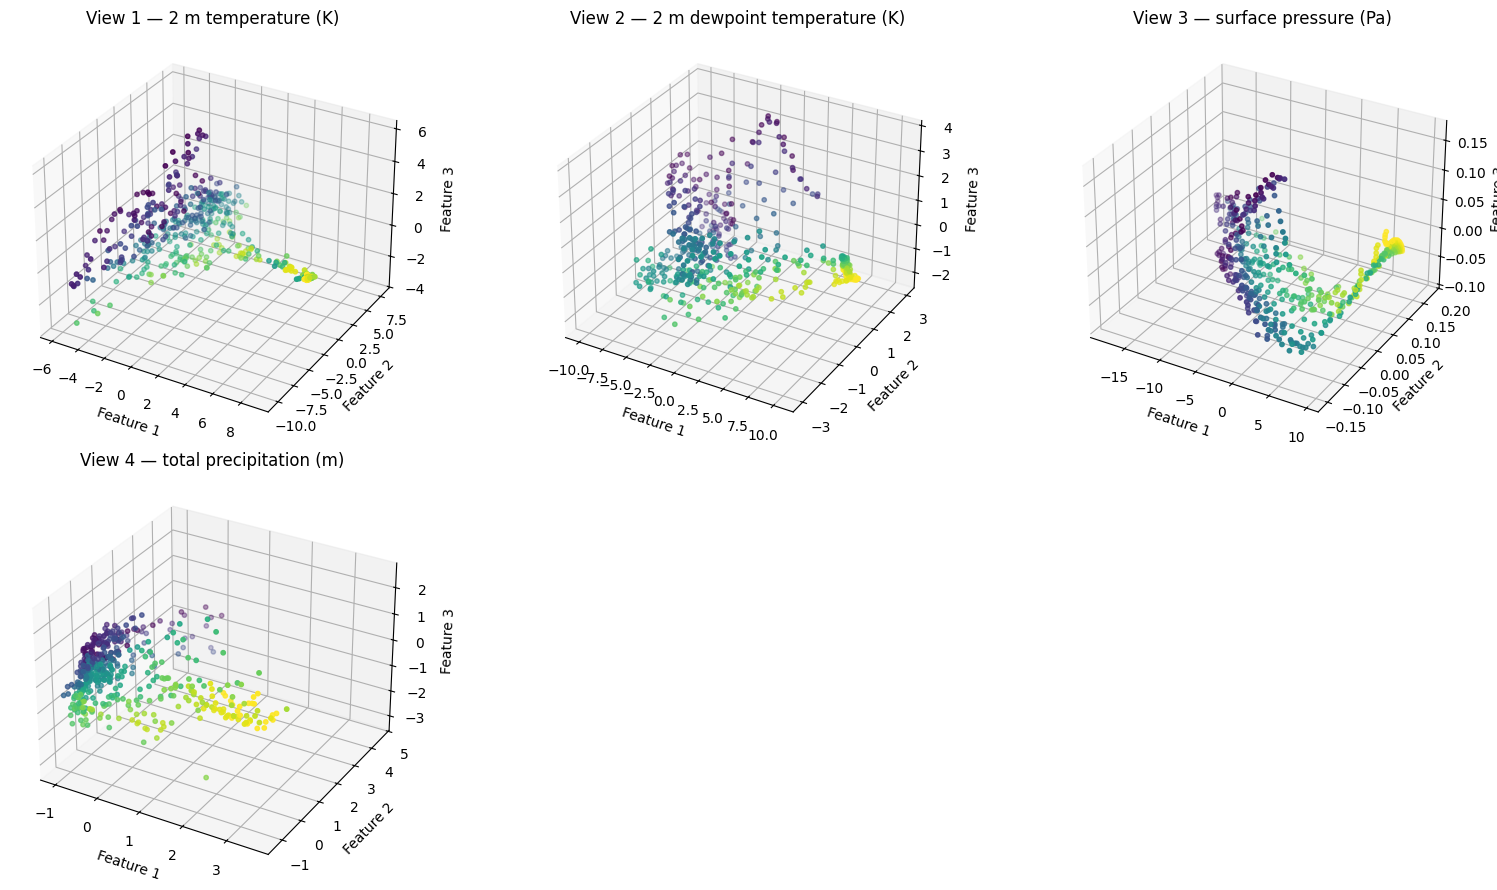

In [ ]:
def plot_input_views(X_views, labels, names=None, max_columns=3):
    n_views = len(X_views)
    names = names or [f"View {v + 1}" for v in range(n_views)]
    n_columns = min(max_columns, n_views)
    n_rows = math.ceil(n_views / n_columns)
    fig = plt.figure(figsize=(5.3 * n_columns, 4.5 * n_rows))

    for view_index, (X_view, name) in enumerate(zip(X_views, names)):
        if X_view.shape[1] > 3:
            X_plot = PCA(n_components=3, random_state=SEED).fit_transform(X_view)
        else:
            X_plot = X_view

        if X_plot.shape[1] >= 3:
            ax = fig.add_subplot(
                n_rows,
                n_columns,
                view_index + 1,
                projection="3d",
            )
            ax.scatter(
                X_plot[:, 0],
                X_plot[:, 1],
                X_plot[:, 2],
                c=labels,
                cmap="viridis",
                s=10,
            )
            ax.set_zlabel("Feature 3")
        else:
            ax = fig.add_subplot(n_rows, n_columns, view_index + 1)
            ax.scatter(
                X_plot[:, 0],
                X_plot[:, 1],
                c=labels,
                cmap="viridis",
                s=10,
            )

        ax.set_title(name)
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")

    fig.tight_layout()
    return fig


plot_input_views(X_views, color_parameter, view_names)
plt.show()


## 3. View-wise relational structures

Each view can use Euclidean, cosine, or graph-geodesic distances. For geodesic distances,
the \(k\)-nearest-neighbor graph is enlarged automatically if needed to obtain a connected
graph. Each distance matrix is normalized independently when `NORMALIZE_DISTANCES=True`.


In [ ]:
def normalize_weights(weights, n_views):
    if weights is None:
        return np.full(n_views, 1.0 / n_views, dtype=np.float64)

    weights = np.asarray(weights, dtype=np.float64)
    if weights.shape != (n_views,):
        raise ValueError(f"Expected {n_views} view weights.")
    if np.any(weights < 0) or weights.sum() <= 0:
        raise ValueError("View weights must be nonnegative and sum to a positive value.")
    return weights / weights.sum()


def normalize_distance_matrix(D, normalize=True, eps=1e-12):
    D = np.asarray(D, dtype=np.float64)
    D = 0.5 * (D + D.T)
    np.fill_diagonal(D, 0.0)
    if not np.isfinite(D).all():
        raise ValueError("The distance matrix contains non-finite values.")
    if normalize:
        scale = max(float(D.max()), eps)
        D = D / scale
    return D.astype(np.float32)


# def geodesic_distance_matrix(X, n_neighbors=12):
#     X = np.asarray(X, dtype=np.float64)
#     n = X.shape[0]
#     if n < 3:
#         raise ValueError("At least three samples are required.")

#     k = min(max(2, int(n_neighbors)), n - 1)
#     while True:
#         graph = kneighbors_graph(
#             X,
#             n_neighbors=k,
#             mode="distance",
#             include_self=False,
#         )
#         graph = graph.maximum(graph.T)
#         n_components, _ = connected_components(graph, directed=False)

#         if n_components == 1:
#             break
#         if k == n - 1:
#             raise RuntimeError("Could not construct a connected neighbor graph.")
#         k = min(n - 1, max(k + 1, int(math.ceil(1.5 * k))))

#     if k != n_neighbors:
#         print(f"  Neighbor graph enlarged from k={n_neighbors} to k={k}.")

#     return shortest_path(graph, directed=False, unweighted=False)


def geodesic_distance_matrix(X, n_neighbors=12):
    X = np.asarray(X, dtype=np.float64)

    if X.shape[0] < 3:
        raise ValueError("At least three samples are required.")

    k = min(max(2, int(n_neighbors)), X.shape[0] - 1)

    isomap = Isomap(
        n_neighbors=k,
        n_components=2
    )
    isomap.fit(X)

    return np.asarray(isomap.dist_matrix_, dtype=np.float64)

def compute_distance_matrix(
    X,
    distance_type="geodesic",
    n_neighbors=12,
    normalize=True,
):
    distance_type = distance_type.lower()
    if distance_type == "geodesic":
        D = geodesic_distance_matrix(X, n_neighbors=n_neighbors)
    elif distance_type == "euclidean":
        D = pairwise_distances(X, metric="euclidean")
    elif distance_type == "cosine":
        D = pairwise_distances(X, metric="cosine")
    else:
        raise ValueError(
            "distance_type must be 'geodesic', 'euclidean', or 'cosine'."
        )
    return normalize_distance_matrix(D, normalize=normalize)


def compute_multiview_distances(
    X_views,
    distance_type="geodesic",
    n_neighbors=12,
    normalize=True,
):
    distances = []
    for view_index, X_view in enumerate(X_views):
        print(f"Computing {distance_type} distances for view {view_index + 1}...")
        distances.append(
            compute_distance_matrix(
                X_view,
                distance_type=distance_type,
                n_neighbors=n_neighbors,
                normalize=normalize,
            )
        )
    return distances


view_weights = normalize_weights(VIEW_WEIGHTS, N_VIEWS)
D_train_views = compute_multiview_distances(
    X_train_views_raw,
    distance_type=DISTANCE_TYPE,
    n_neighbors=N_NEIGHBORS,
    normalize=NORMALIZE_DISTANCES,
)
if DISTANCE_TYPE == "geodesic":
    X_full_views_raw = [
        np.concatenate([X_train, X_test], axis=0)
        for X_train, X_test in zip(
            X_train_views_raw,
            X_test_views_raw,
        )
    ]

    D_full_views = compute_multiview_distances(
        X_full_views_raw,
        distance_type=DISTANCE_TYPE,
        n_neighbors=N_NEIGHBORS,
        normalize=False,
    )

    D_test_views = []

    for D_full, X_train in zip(
        D_full_views,
        X_train_views_raw,
    ):
        n_train = len(X_train)

        D_test = D_full[
            n_train:,
            n_train:
        ].copy()

        if NORMALIZE_DISTANCES:
            max_distance = np.max(D_test)
            if max_distance > 0:
                D_test = D_test / max_distance

        D_test_views.append(D_test)

else:
    D_test_views = compute_multiview_distances(
        X_test_views_raw,
        distance_type=DISTANCE_TYPE,
        n_neighbors=N_NEIGHBORS,
        normalize=NORMALIZE_DISTANCES,
    )

print("Normalized view weights:", np.round(view_weights, 4))


Computing geodesic distances for view 1...
Computing geodesic distances for view 2...
Computing geodesic distances for view 3...
Computing geodesic distances for view 4...
Computing geodesic distances for view 1...
Computing geodesic distances for view 2...
Computing geodesic distances for view 3...
Computing geodesic distances for view 4...
Normalized view weights: [0.25 0.25 0.25 0.25]


## 4. GW-MDS utilities

The transport plan is recomputed with the current embedding and held fixed during the
gradient update. After the final update, the plan is recomputed once more. For a plan
\(T^\star\), the sample-indexed barycentric target is

\[
\widetilde Y
=
\operatorname{Diag}(T^\star\mathbf 1)^{-1}T^\star Z^\star.
\]


In [ ]:
def to_torch(array, device=DEVICE):
    return torch.as_tensor(array, dtype=torch.float32, device=device)


def uniform_mass(n, device=DEVICE):
    return torch.full((n,), 1.0 / n, dtype=torch.float32, device=device)


# def initialize_embedding_from_distance(
#     D,
#     n_components=2,
#     init="random",
#     seed=42,
# ):
#     D = np.asarray(D, dtype=np.float64)
#     n = D.shape[0]

#     if init == "random":
#         generator = torch.Generator().manual_seed(seed)
#         Y0 = torch.randn(n, n_components, generator=generator)
#     elif init == "classical_mds":
#         centering = np.eye(n) - np.ones((n, n)) / n
#         gram = -0.5 * centering @ (D ** 2) @ centering
#         eigenvalues, eigenvectors = np.linalg.eigh(gram)
#         order = np.argsort(eigenvalues)[::-1][:n_components]
#         positive = np.maximum(eigenvalues[order], 0.0)
#         Y0_np = eigenvectors[:, order] * np.sqrt(positive)[None, :]
#         Y0 = torch.tensor(Y0_np, dtype=torch.float32)
#     else:
#         raise ValueError("init must be 'random' or 'classical_mds'.")

#     diameter = torch.cdist(Y0, Y0).max().clamp_min(1e-12)
#     return Y0 / diameter

def initialize_embedding_from_distance(
    D,
    n_components=2,
    init="random",
    seed=0,
    normalize_diameter=False,
):
    D = np.asarray(D, dtype=np.float64)
    n = D.shape[0]

    if init == "random":
        generator = torch.Generator().manual_seed(seed)

        Y0 = torch.randn(
            n,
            n_components,
            generator=generator,
            dtype=torch.float32,
        )

    elif init == "classical_mds":
        centering = np.eye(n) - np.ones((n, n)) / n
        gram = -0.5 * centering @ (D ** 2) @ centering

        eigenvalues, eigenvectors = np.linalg.eigh(gram)
        order = np.argsort(eigenvalues)[::-1][:n_components]
        positive = np.maximum(eigenvalues[order], 0.0)

        Y0_np = (
            eigenvectors[:, order]
            * np.sqrt(positive)[None, :]
        )

        Y0 = torch.tensor(
            Y0_np,
            dtype=torch.float32,
        )

    else:
        raise ValueError(
            "init must be 'random' or 'classical_mds'."
        )

    if normalize_diameter:
        diameter = torch.cdist(Y0, Y0).max().clamp_min(1e-12)
        Y0 = Y0 / diameter

    return Y0


def squared_gw_loss_fixed_plan(DX, DY, T, a, b):
    const_x = torch.sum(DX.square() * torch.outer(a, a))
    const_y = torch.sum(DY.square() * torch.outer(b, b))
    cross = torch.sum((DX @ T @ DY.T) * T)
    return const_x + const_y - 2.0 * cross


def solve_gw_plan(
    DX,
    DY,
    a,
    b,
    initial_plan=None,
    inner_max_iter=100,
    tol=1e-5,
):
    kwargs = {}
    if initial_plan is not None:
        kwargs["G0"] = initial_plan

    return ot.gromov.gromov_wasserstein(
        DX,
        DY,
        a,
        b,
        loss_fun="square_loss",
        symmetric=True,
        armijo=False,
        log=False,
        verbose=False,
        max_iter=inner_max_iter,
        tol_rel=tol,
        tol_abs=tol,
        **kwargs,
    )


def barycentric_projection(Y_support, T):
    row_mass = T.sum(dim=1, keepdim=True).clamp_min(1e-12)
    return (T @ Y_support) / row_mass


def upper_triangle_values(D):
    D = np.asarray(D)
    return D[np.triu_indices_from(D, k=1)]


def upper_pearson(D1, D2):
    x = upper_triangle_values(D1)
    y = upper_triangle_values(D2)
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 2:
        return np.nan
    return float(pearsonr(x[valid], y[valid])[0])


## 5. Mean-GWMDS teacher

Mean-GWMDS uses

\[
\overline D_X=\sum_{v=1}^{V}\lambda_vD_X^{(v)}
\]

and therefore produces one transport plan and one barycentric target.


In [ ]:
def fit_gwmds_from_distance(
    D_source_np,
    n_components=2,
    n_iterations=100,
    lr=0.1,
    init="random",
    seed=42,
    inner_max_iter=100,
    tol=1e-5,
    print_every=10,
    device=DEVICE,
    label="GW-MDS",
):
    set_seed(seed)
    start = time.perf_counter()

    D_source = to_torch(D_source_np, device)
    n = D_source.shape[0]
    a = uniform_mass(n, device)
    b = uniform_mass(n, device)

    Y = initialize_embedding_from_distance(
        D_source_np,
        n_components=n_components,
        init=init,
        seed=seed,
    ).to(device)
    Y.requires_grad_(True)

    optimizer = torch.optim.Adam([Y], lr=lr)
    history = []
    plan = None

    for iteration in range(1, n_iterations + 1):
        optimizer.zero_grad()
        DY = torch.cdist(Y, Y, p=2)

        with torch.no_grad():
            plan = solve_gw_plan(
                D_source,
                DY.detach(),
                a,
                b,
                # initial_plan=plan,
                initial_plan=None,
                inner_max_iter=inner_max_iter,
                tol=tol,
            )

        loss = squared_gw_loss_fixed_plan(D_source, DY, plan, a, b)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            Y -= Y.mean(dim=0, keepdim=True)

        history.append(float(loss.detach()))
        if iteration == 1 or iteration % print_every == 0:
            print(
                f"{label} {iteration:03d}/{n_iterations} | "
                f"loss={history[-1]:.8f}"
            )

    with torch.no_grad():
        DY_final = torch.cdist(Y, Y, p=2)
        final_plan = solve_gw_plan(
            D_source,
            DY_final,
            a,
            b,
            # initial_plan=plan,
            initial_plan=None,
            inner_max_iter=inner_max_iter,
            tol=tol,
        )
        Y_projected = barycentric_projection(Y, final_plan)
        final_loss = squared_gw_loss_fixed_plan(
            D_source,
            DY_final,
            final_plan,
            a,
            b,
        )

    return {
        "Y_support": Y.detach().cpu().numpy(),
        "T_final": final_plan.detach().cpu().numpy(),
        "Y_projected": Y_projected.detach().cpu().numpy(),
        "history": np.asarray(history),
        "final_loss": float(final_loss),
        "execution_time": time.perf_counter() - start,
    }


def fit_mean_gwmds_teacher(D_views, weights, **kwargs):
    weights = normalize_weights(weights, len(D_views))
    D_mean = np.zeros_like(np.asarray(D_views[0]), dtype=np.float64)
    for weight, D_view in zip(weights, D_views):
        D_mean += weight * np.asarray(D_view, dtype=np.float64)

    result = fit_gwmds_from_distance(
        D_mean.astype(np.float32),
        label="Mean-GWMDS teacher",
        **kwargs,
    )
    result["D_mean"] = D_mean.astype(np.float32)
    result["weights"] = weights
    return result


mean_teacher = fit_mean_gwmds_teacher(
    D_train_views,
    view_weights,
    n_components=EMBEDDING_DIM,
    n_iterations=TEACHER_ITERATIONS,
    lr=TEACHER_LR,
    init=TEACHER_INIT,
    seed=SEED,
    inner_max_iter=GW_INNER_MAX_ITER,
    tol=GW_TOL,
    print_every=PRINT_EVERY,
    device=DEVICE,
)

Y_mean_teacher_train = mean_teacher["Y_projected"]
print(
    f"Mean-GWMDS teacher completed in "
    f"{mean_teacher['execution_time']:.2f} seconds."
)


Mean-GWMDS teacher 001/100 | loss=2.86921525
Mean-GWMDS teacher 010/100 | loss=0.49850440
Mean-GWMDS teacher 020/100 | loss=0.08329573
Mean-GWMDS teacher 030/100 | loss=0.01752806
Mean-GWMDS teacher 040/100 | loss=0.00525618
Mean-GWMDS teacher 050/100 | loss=0.00479183
Mean-GWMDS teacher 060/100 | loss=0.00278360
Mean-GWMDS teacher 070/100 | loss=0.00244343
Mean-GWMDS teacher 080/100 | loss=0.00250414
Mean-GWMDS teacher 090/100 | loss=0.00463724
Mean-GWMDS teacher 100/100 | loss=0.00231472
Mean-GWMDS teacher completed in 80.58 seconds.


## 6. Multi-GWMDS teacher and separate barycentric projections

Multi-GWMDS solves

\[
\min_{Z,\{T^{(v)}\}}
\sum_{v=1}^{V}\lambda_v
\mathcal L_{\mathrm{GW}}\!\left(D_X^{(v)},D_Z,T^{(v)}\right).
\]

The final support \(Z^\star\) is shared, but each view produces its own plan and target

\[
\widetilde Y^{(v)}
=
\operatorname{Diag}(T^{(v)}\mathbf 1)^{-1}T^{(v)}Z^\star.
\]

These projections are evaluated and stored separately. One projection is selected for the
representative-output experiment, but the projections are never averaged.


In [ ]:
def fit_multi_gwmds_teacher(
    D_views_np,
    weights=None,
    n_components=2,
    n_iterations=100,
    lr=0.1,
    init="random",
    seed=42,
    inner_max_iter=100,
    tol=1e-5,
    print_every=10,
    device=DEVICE,
):
    set_seed(seed)
    start = time.perf_counter()

    weights = normalize_weights(weights, len(D_views_np))
    D_views = [to_torch(D, device) for D in D_views_np]
    n = D_views[0].shape[0]
    if any(D.shape != (n, n) for D in D_views):
        raise ValueError("All training distance matrices must have shape (n, n).")

    D_reference = sum(
        weight * np.asarray(D_view, dtype=np.float64)
        for weight, D_view in zip(weights, D_views_np)
    )
    Y = initialize_embedding_from_distance(
        D_reference,
        n_components=n_components,
        init=init,
        seed=seed,
    ).to(device)
    Y.requires_grad_(True)

    a = uniform_mass(n, device)
    b = uniform_mass(n, device)
    optimizer = torch.optim.Adam([Y], lr=lr)
    plans = [None] * len(D_views)
    total_history = []
    view_history = []

    for iteration in range(1, n_iterations + 1):
        optimizer.zero_grad()
        DY = torch.cdist(Y, Y, p=2)
        total_loss = torch.zeros((), dtype=torch.float32, device=device)
        losses_this_iteration = []

        for view_index, (weight, D_view) in enumerate(
            zip(weights, D_views)
        ):
            with torch.no_grad():
                plans[view_index] = solve_gw_plan(
                    D_view,
                    DY.detach(),
                    a,
                    b,
                    # initial_plan=plans[view_index],
                    initial_plan=None,
                    inner_max_iter=inner_max_iter,
                    tol=tol,
                )

            loss_view = squared_gw_loss_fixed_plan(
                D_view,
                DY,
                plans[view_index],
                a,
                b,
            )
            total_loss = total_loss + float(weight) * loss_view
            losses_this_iteration.append(float(loss_view.detach()))

        total_loss.backward()
        optimizer.step()

        with torch.no_grad():
            Y -= Y.mean(dim=0, keepdim=True)

        total_history.append(float(total_loss.detach()))
        view_history.append(losses_this_iteration)

        if iteration == 1 or iteration % print_every == 0:
            view_text = " | ".join(
                f"view {v + 1}={value:.6f}"
                for v, value in enumerate(losses_this_iteration)
            )
            print(
                f"Multi-GWMDS teacher {iteration:03d}/{n_iterations} | "
                f"total={total_history[-1]:.8f} | {view_text}"
            )

    with torch.no_grad():
        DY_final = torch.cdist(Y, Y, p=2)
        final_plans = []
        projections = []
        final_losses = []

        for view_index, D_view in enumerate(D_views):
            final_plan = solve_gw_plan(
                D_view,
                DY_final,
                a,
                b,
                # initial_plan=plans[view_index],
                initial_plan=None,
                inner_max_iter=inner_max_iter,
                tol=tol,
            )
            projection = barycentric_projection(Y, final_plan)
            final_loss = squared_gw_loss_fixed_plan(
                D_view,
                DY_final,
                final_plan,
                a,
                b,
            )
            final_plans.append(final_plan.detach().cpu().numpy())
            projections.append(projection.detach().cpu().numpy())
            final_losses.append(float(final_loss))

    return {
        "Y_support": Y.detach().cpu().numpy(),
        "T_final_list": final_plans,
        "Y_projected_list": projections,
        "history_total": np.asarray(total_history),
        "history_views": np.asarray(view_history),
        "final_losses": np.asarray(final_losses),
        "weights": weights,
        "execution_time": time.perf_counter() - start,
    }


def select_barycentric_projection(
    projected_embeddings,
    D_views,
    criterion="mean",
):
    n_projections = len(projected_embeddings)
    n_views = len(D_views)
    agreement = np.zeros((n_projections, n_views), dtype=np.float64)

    for projection_index, Y_projection in enumerate(projected_embeddings):
        D_projection = pairwise_distances(Y_projection)
        for view_index, D_view in enumerate(D_views):
            agreement[projection_index, view_index] = upper_pearson(
                D_projection,
                D_view,
            )

    if criterion == "mean":
        scores = agreement.mean(axis=1)
    elif criterion == "median":
        scores = np.median(agreement, axis=1)
    elif criterion == "maximin":
        scores = agreement.min(axis=1)
    else:
        raise ValueError("criterion must be 'mean', 'median', or 'maximin'.")

    selected_index = int(np.nanargmax(scores))
    return {
        "selected_index": selected_index,
        "agreement_matrix": agreement,
        "scores": scores,
        "criterion": criterion,
    }


multi_teacher = fit_multi_gwmds_teacher(
    D_train_views,
    weights=view_weights,
    n_components=EMBEDDING_DIM,
    n_iterations=TEACHER_ITERATIONS,
    lr=TEACHER_LR,
    init=TEACHER_INIT,
    seed=SEED,
    inner_max_iter=GW_INNER_MAX_ITER,
    tol=GW_TOL,
    print_every=PRINT_EVERY,
    device=DEVICE,
)

selection = select_barycentric_projection(
    multi_teacher["Y_projected_list"],
    D_train_views,
    criterion=SELECTION_CRITERION,
)
selected_view = selection["selected_index"]
Y_selected_teacher_train = multi_teacher["Y_projected_list"][selected_view]

agreement_table = pd.DataFrame(
    selection["agreement_matrix"],
    index=[f"Projection from view {v + 1}" for v in range(N_VIEWS)],
    columns=[f"Geometry of view {v + 1}" for v in range(N_VIEWS)],
)
agreement_table["Selection score"] = selection["scores"]
display(agreement_table.style.format("{:.4f}"))

print(
    f"Selected projection: view {selected_view + 1} "
    f"using criterion='{SELECTION_CRITERION}'."
)
print(
    f"Multi-GWMDS teacher completed in "
    f"{multi_teacher['execution_time']:.2f} seconds."
)


Multi-GWMDS teacher 001/100 | total=2.84863329 | view 1=2.738826 | view 2=2.637334 | view 3=3.033900 | view 4=2.984473
Multi-GWMDS teacher 010/100 | total=0.48579445 | view 1=0.456724 | view 2=0.439636 | view 3=0.545932 | view 4=0.500885
Multi-GWMDS teacher 020/100 | total=0.08725134 | view 1=0.078498 | view 2=0.069097 | view 3=0.115994 | view 4=0.085417
Multi-GWMDS teacher 030/100 | total=0.02476287 | view 1=0.021117 | view 2=0.018307 | view 3=0.030336 | view 4=0.029291
Multi-GWMDS teacher 040/100 | total=0.01317038 | view 1=0.009816 | view 2=0.012303 | view 3=0.013732 | view 4=0.016830
Multi-GWMDS teacher 050/100 | total=0.01234032 | view 1=0.009358 | view 2=0.014021 | view 3=0.010048 | view 4=0.015935
Multi-GWMDS teacher 060/100 | total=0.01146724 | view 1=0.008768 | view 2=0.011908 | view 3=0.009284 | view 4=0.015909
Multi-GWMDS teacher 070/100 | total=0.01146425 | view 1=0.008538 | view 2=0.012013 | view 3=0.009168 | view 4=0.016137
Multi-GWMDS teacher 080/100 | total=0.01144284 |

,Geometry of view 1,Geometry of view 2,Geometry of view 3,Geometry of view 4,Selection score
Projection from view 1,0.9272,0.7387,0.7035,0.5734,0.7357
Projection from view 2,0.7063,0.9065,0.7852,0.3998,0.6995
Projection from view 3,0.7073,0.7270,0.9327,0.3451,0.6780
Projection from view 4,0.7271,0.5613,0.5093,0.7833,0.6453


Selected projection: view 1 using criterion='mean'.
Multi-GWMDS teacher completed in 229.60 seconds.


## 7. General multi-view students

`MultiViewStudent` creates one encoder for each input view and combines the encoded features
to predict a single teacher target. This feature-level operation is not an average of
barycentric projections.

For the view-specific experiment, the same class is instantiated with one view at a time:

\[
f_{\theta_v}\!\left(X^{(v)}\right)
\approx
\widetilde Y^{(v)}.
\]


In [ ]:
class ViewEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

    def forward(self, X):
        return self.network(X)


class MultiViewStudent(nn.Module):
    def __init__(self, input_dims, output_dim=2, hidden_dim=64):
        super().__init__()
        if len(input_dims) == 0:
            raise ValueError("At least one input view is required.")

        self.encoders = nn.ModuleList(
            [ViewEncoder(input_dim, hidden_dim) for input_dim in input_dims]
        )
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim * len(input_dims), hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, X_views):
        if len(X_views) != len(self.encoders):
            raise ValueError("The number of input tensors does not match the model.")
        encoded = [
            encoder(X_view)
            for encoder, X_view in zip(self.encoders, X_views)
        ]
        return self.output_head(torch.cat(encoded, dim=1))


def arrays_to_tensors(arrays, indices=None, device=DEVICE):
    if indices is None:
        return [to_torch(array, device) for array in arrays]
    return [to_torch(array[indices], device) for array in arrays]


def fit_distilled_student(
    X_train_views,
    Y_target,
    hidden_dim=64,
    max_epochs=3000,
    patience=250,
    lr=1e-3,
    weight_decay=1e-5,
    validation_size=0.15,
    seed=42,
    device=DEVICE,
    label="Distilled student",
):
    set_seed(seed)
    start = time.perf_counter()
    n = len(Y_target)
    indices = np.arange(n)
    fit_indices, validation_indices = train_test_split(
        indices,
        test_size=validation_size,
        random_state=seed,
        shuffle=True,
    )

    target_scaler = StandardScaler()
    target_scaler.fit(Y_target[fit_indices])
    Y_scaled = target_scaler.transform(Y_target).astype(np.float32)

    model = MultiViewStudent(
        input_dims=[X.shape[1] for X in X_train_views],
        output_dim=Y_target.shape[1],
        hidden_dim=hidden_dim,
    ).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )
    criterion = nn.MSELoss()

    X_fit = arrays_to_tensors(X_train_views, fit_indices, device)
    X_validation = arrays_to_tensors(
        X_train_views,
        validation_indices,
        device,
    )
    Y_fit = to_torch(Y_scaled[fit_indices], device)
    Y_validation = to_torch(Y_scaled[validation_indices], device)

    best_state = None
    best_validation = np.inf
    wait = 0
    train_history = []
    validation_history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()
        train_loss = criterion(model(X_fit), Y_fit)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            validation_loss = criterion(
                model(X_validation),
                Y_validation,
            )

        train_value = float(train_loss.detach())
        validation_value = float(validation_loss.detach())
        train_history.append(train_value)
        validation_history.append(validation_value)

        if validation_value < best_validation - 1e-8:
            best_validation = validation_value
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if epoch == 1 or epoch % 250 == 0:
            print(
                f"{label} {epoch:04d}/{max_epochs} | "
                f"train={train_value:.6f} | "
                f"validation={validation_value:.6f}"
            )

        if wait >= patience:
            print(
                f"{label}: early stopping at epoch {epoch}; "
                f"best validation={best_validation:.6f}"
            )
            break

    if best_state is None:
        raise RuntimeError("No valid student state was obtained.")
    model.load_state_dict(best_state)

    return {
        "model": model,
        "target_scaler": target_scaler,
        "history_train": np.asarray(train_history),
        "history_validation": np.asarray(validation_history),
        "best_validation": best_validation,
        "execution_time": time.perf_counter() - start,
        "device": device,
        "label": label,
    }


def predict_distilled_student(student_result, X_views):
    model = student_result["model"]
    device = student_result["device"]
    model.eval()
    with torch.no_grad():
        prediction_scaled = model(
            arrays_to_tensors(X_views, device=device)
        ).cpu().numpy()
    return student_result["target_scaler"].inverse_transform(
        prediction_scaled
    )


In [ ]:
mean_student = fit_distilled_student(
    X_train_views,
    Y_mean_teacher_train,
    hidden_dim=STUDENT_HIDDEN_DIM,
    max_epochs=STUDENT_MAX_EPOCHS,
    patience=STUDENT_PATIENCE,
    lr=STUDENT_LR,
    weight_decay=STUDENT_WEIGHT_DECAY,
    validation_size=VALIDATION_SIZE,
    seed=SEED,
    device=DEVICE,
    label="Inductive Mean-GWMDS student",
)
Y_mean_student_train = predict_distilled_student(
    mean_student,
    X_train_views,
)
Y_mean_student_test = predict_distilled_student(
    mean_student,
    X_test_views,
)

selected_student = fit_distilled_student(
    X_train_views,
    Y_selected_teacher_train,
    hidden_dim=STUDENT_HIDDEN_DIM,
    max_epochs=STUDENT_MAX_EPOCHS,
    patience=STUDENT_PATIENCE,
    lr=STUDENT_LR,
    weight_decay=STUDENT_WEIGHT_DECAY,
    validation_size=VALIDATION_SIZE,
    seed=SEED,
    device=DEVICE,
    label="Inductive Multi-GWMDS selected-projection student",
)
Y_selected_student_train = predict_distilled_student(
    selected_student,
    X_train_views,
)
Y_selected_student_test = predict_distilled_student(
    selected_student,
    X_test_views,
)

view_specific_students = []
Y_view_specific_train = []
Y_view_specific_test = []

for view_index in range(N_VIEWS):
    result = fit_distilled_student(
        [X_train_views[view_index]],
        multi_teacher["Y_projected_list"][view_index],
        hidden_dim=STUDENT_HIDDEN_DIM,
        max_epochs=STUDENT_MAX_EPOCHS,
        patience=STUDENT_PATIENCE,
        lr=STUDENT_LR,
        weight_decay=STUDENT_WEIGHT_DECAY,
        validation_size=VALIDATION_SIZE,
        seed=SEED + view_index,
        device=DEVICE,
        label=f"View-specific student {view_index + 1}",
    )
    view_specific_students.append(result)
    Y_view_specific_train.append(
        predict_distilled_student(
            result,
            [X_train_views[view_index]],
        )
    )
    Y_view_specific_test.append(
        predict_distilled_student(
            result,
            [X_test_views[view_index]],
        )
    )

print("All barycentric distillation models completed.")


Inductive Mean-GWMDS student 0001/3000 | train=1.061157 | validation=0.854895
Inductive Mean-GWMDS student 0250/3000 | train=0.000053 | validation=0.002668
Inductive Mean-GWMDS student: early stopping at epoch 481; best validation=0.002660
Inductive Multi-GWMDS selected-projection student 0001/3000 | train=1.054621 | validation=0.816010
Inductive Multi-GWMDS selected-projection student 0250/3000 | train=0.000096 | validation=0.051618
Inductive Multi-GWMDS selected-projection student: early stopping at epoch 297; best validation=0.037685
View-specific student 1 0001/3000 | train=1.040635 | validation=0.881285
View-specific student 1 0250/3000 | train=0.008357 | validation=0.024432
View-specific student 1 0500/3000 | train=0.003936 | validation=0.029356
View-specific student 1: early stopping at epoch 563; best validation=0.023926
View-specific student 2 0001/3000 | train=1.005888 | validation=0.940044
View-specific student 2 0250/3000 | train=0.006815 | validation=0.025302
View-specific

## 8. Direct multi-view GW training

This baseline optimizes

\[
\min_\theta
\sum_{v=1}^{V}\lambda_v
\operatorname{GW}^2
\left(D_X^{(v)},D_{F_\theta(\mathcal X)}\right).
\]

It uses the network output directly and does not construct a barycentric teacher target.
The training output normalization is reused unchanged at test time.


In [ ]:
def normalize_training_embedding(Y_raw):
    output_mean = Y_raw.mean(dim=0, keepdim=True)
    Y_centered = Y_raw - output_mean
    output_scale = torch.cdist(
        Y_centered,
        Y_centered,
        p=2,
    ).max().clamp_min(1e-12)
    return Y_centered / output_scale, output_mean, output_scale


def fit_direct_multiview_gw_student(
    X_train_views,
    D_train_views,
    weights=None,
    output_dim=2,
    hidden_dim=64,
    n_iterations=100,
    lr=1e-3,
    weight_decay=1e-5,
    inner_max_iter=100,
    tol=1e-5,
    seed=42,
    print_every=10,
    device=DEVICE,
):
    set_seed(seed)
    start = time.perf_counter()
    weights = normalize_weights(weights, len(D_train_views))
    D_views = [to_torch(D, device) for D in D_train_views]
    X_tensors = arrays_to_tensors(X_train_views, device=device)

    n = D_views[0].shape[0]
    a = uniform_mass(n, device)
    b = uniform_mass(n, device)
    model = MultiViewStudent(
        input_dims=[X.shape[1] for X in X_train_views],
        output_dim=output_dim,
        hidden_dim=hidden_dim,
    ).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    plans = [None] * len(D_views)
    history_total = []
    history_views = []

    for iteration in range(1, n_iterations + 1):
        model.train()
        optimizer.zero_grad()
        Y_raw = model(X_tensors)
        Y_train, _, _ = normalize_training_embedding(Y_raw)
        DY = torch.cdist(Y_train, Y_train, p=2)

        total_loss = torch.zeros((), dtype=torch.float32, device=device)
        losses_this_iteration = []

        for view_index, (weight, D_view) in enumerate(
            zip(weights, D_views)
        ):
            with torch.no_grad():
                plans[view_index] = solve_gw_plan(
                    D_view,
                    DY.detach(),
                    a,
                    b,
                    # initial_plan=plans[view_index],
                    initial_plan=None,
                    inner_max_iter=inner_max_iter,
                    tol=tol,
                )

            loss_view = squared_gw_loss_fixed_plan(
                D_view,
                DY,
                plans[view_index],
                a,
                b,
            )
            total_loss = total_loss + float(weight) * loss_view
            losses_this_iteration.append(float(loss_view.detach()))

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()

        history_total.append(float(total_loss.detach()))
        history_views.append(losses_this_iteration)

        if iteration == 1 or iteration % print_every == 0:
            view_text = " | ".join(
                f"view {v + 1}={value:.6f}"
                for v, value in enumerate(losses_this_iteration)
            )
            print(
                f"Direct multi-view GW {iteration:03d}/{n_iterations} | "
                f"total={history_total[-1]:.8f} | {view_text}"
            )

    model.eval()
    with torch.no_grad():
        Y_raw = model(X_tensors)
        Y_train, output_mean, output_scale = normalize_training_embedding(
            Y_raw
        )
        DY_final = torch.cdist(Y_train, Y_train, p=2)
        final_losses = []
        final_plans = []

        for view_index, D_view in enumerate(D_views):
            final_plan = solve_gw_plan(
                D_view,
                DY_final,
                a,
                b,
                # initial_plan=plans[view_index],
                initial_plan=None,
                inner_max_iter=inner_max_iter,
                tol=tol,
            )
            final_loss = squared_gw_loss_fixed_plan(
                D_view,
                DY_final,
                final_plan,
                a,
                b,
            )
            final_plans.append(final_plan.detach().cpu().numpy())
            final_losses.append(float(final_loss))

    return {
        "model": model,
        "Y_train": Y_train.detach().cpu().numpy(),
        "output_mean": output_mean.detach().cpu().numpy(),
        "output_scale": float(output_scale),
        "T_final_list": final_plans,
        "final_losses": np.asarray(final_losses),
        "history_total": np.asarray(history_total),
        "history_views": np.asarray(history_views),
        "execution_time": time.perf_counter() - start,
        "weights": weights,
        "device": device,
    }


def predict_direct_multiview_gw(direct_result, X_views):
    model = direct_result["model"]
    device = direct_result["device"]
    model.eval()
    with torch.no_grad():
        Y_raw = model(arrays_to_tensors(X_views, device=device))
        output_mean = to_torch(direct_result["output_mean"], device)
        output_scale = torch.tensor(
            direct_result["output_scale"],
            dtype=torch.float32,
            device=device,
        )
        Y = (Y_raw - output_mean) / output_scale.clamp_min(1e-12)
    return Y.cpu().numpy()


direct_result = None
Y_direct_train = None
Y_direct_test = None

if RUN_DIRECT_GW:
    direct_result = fit_direct_multiview_gw_student(
        X_train_views,
        D_train_views,
        weights=view_weights,
        output_dim=EMBEDDING_DIM,
        hidden_dim=STUDENT_HIDDEN_DIM,
        n_iterations=DIRECT_GW_ITERATIONS,
        lr=DIRECT_GW_LR,
        weight_decay=DIRECT_GW_WEIGHT_DECAY,
        inner_max_iter=GW_INNER_MAX_ITER,
        tol=GW_TOL,
        seed=SEED,
        print_every=PRINT_EVERY,
        device=DEVICE,
    )
    Y_direct_train = direct_result["Y_train"]
    Y_direct_test = predict_direct_multiview_gw(
        direct_result,
        X_test_views,
    )


Direct multi-view GW 001/100 | total=0.02085103 | view 1=0.018341 | view 2=0.033961 | view 3=0.009302 | view 4=0.021801
Direct multi-view GW 010/100 | total=0.01496720 | view 1=0.014342 | view 2=0.022093 | view 3=0.006212 | view 4=0.017221
Direct multi-view GW 020/100 | total=0.01325797 | view 1=0.007725 | view 2=0.015175 | view 3=0.011502 | view 4=0.018630
Direct multi-view GW 030/100 | total=0.01210560 | view 1=0.008974 | view 2=0.014510 | view 3=0.008944 | view 4=0.015995
Direct multi-view GW 040/100 | total=0.01201928 | view 1=0.009071 | view 2=0.014262 | view 3=0.007906 | view 4=0.016838
Direct multi-view GW 050/100 | total=0.01209284 | view 1=0.009841 | view 2=0.012837 | view 3=0.009181 | view 4=0.016512
Direct multi-view GW 060/100 | total=0.01213416 | view 1=0.009398 | view 2=0.014459 | view 3=0.009207 | view 4=0.015473
Direct multi-view GW 070/100 | total=0.01156352 | view 1=0.008555 | view 2=0.012881 | view 3=0.009122 | view 4=0.015696
Direct multi-view GW 080/100 | total=0.0

## 9. Relational evaluation

Pearson, Spearman, scale-adjusted stress, and trustworthiness are computed against each
view separately. The `Weighted mean` row uses the configured view weights.

For the view-specific students, the full cross-view table is retained: every student output
is evaluated against every view geometry. This makes it possible to verify whether each
student preserves the geometry associated with its own teacher target.


In [ ]:
def relational_metrics_from_distance(
    D_source,
    Y,
    n_neighbors=10,
):
    D_source = np.asarray(D_source, dtype=np.float64)
    D_embedding = pairwise_distances(Y, metric="euclidean")
    source_values = upper_triangle_values(D_source)
    embedding_values = upper_triangle_values(D_embedding)
    valid = np.isfinite(source_values) & np.isfinite(embedding_values)
    source_values = source_values[valid]
    embedding_values = embedding_values[valid]

    pearson = float(pearsonr(source_values, embedding_values)[0])
    spearman = float(spearmanr(source_values, embedding_values)[0])

    denominator = max(
        float(np.dot(embedding_values, embedding_values)),
        1e-12,
    )
    alpha = float(
        np.dot(source_values, embedding_values) / denominator
    )
    stress = float(
        np.sqrt(
            np.sum((source_values - alpha * embedding_values) ** 2)
            / max(np.sum(source_values ** 2), 1e-12)
        )
    )

    safe_neighbors = min(
        int(n_neighbors),
        max(1, D_source.shape[0] // 2 - 1),
    )
    trust = float(
        trustworthiness(
            D_source,
            Y,
            n_neighbors=safe_neighbors,
            metric="precomputed",
        )
    )

    return {
        "Pearson": pearson,
        "Spearman": spearman,
        "Trustworthiness": trust,
        "Stress": stress,
        "Scale": alpha,
    }


def evaluate_embedding_against_views(
    method_name,
    Y,
    D_views,
    weights,
    split="Test",
):
    weights = normalize_weights(weights, len(D_views))
    rows = []
    metrics_per_view = []

    for view_index, D_view in enumerate(D_views):
        metrics = relational_metrics_from_distance(
            D_view,
            Y,
            n_neighbors=TRUSTWORTHINESS_NEIGHBORS,
        )
        metrics_per_view.append(metrics)
        rows.append(
            {
                "Method": method_name,
                "Split": split,
                "Evaluated geometry": f"View {view_index + 1}",
                **metrics,
            }
        )

    weighted_metrics = {
        key: float(
            sum(
                weight * metrics[key]
                for weight, metrics in zip(weights, metrics_per_view)
            )
        )
        for key in [
            "Pearson",
            "Spearman",
            "Trustworthiness",
            "Stress",
            "Scale",
        ]
    }
    rows.append(
        {
            "Method": method_name,
            "Split": split,
            "Evaluated geometry": "Weighted mean",
            **weighted_metrics,
        }
    )
    return rows


# Concatenated PCA baseline: all feature scalers were fitted only on train.
X_train_concatenated = np.concatenate(X_train_views, axis=1)
X_test_concatenated = np.concatenate(X_test_views, axis=1)
pca = PCA(n_components=EMBEDDING_DIM, random_state=SEED)
Y_pca_train = pca.fit_transform(X_train_concatenated)
Y_pca_test = pca.transform(X_test_concatenated)

common_test_embeddings = {
    "Inductive Mean-GWMDS": Y_mean_student_test,
    "Inductive Multi-GWMDS — selected projection": Y_selected_student_test,
    "Concatenated PCA": Y_pca_test,
}
if RUN_DIRECT_GW:
    common_test_embeddings["Direct multi-view GW"] = Y_direct_test

evaluation_rows = []
for method_name, Y_test in common_test_embeddings.items():
    evaluation_rows.extend(
        evaluate_embedding_against_views(
            method_name,
            Y_test,
            D_test_views,
            view_weights,
            split="Test",
        )
    )

for student_index, Y_test in enumerate(Y_view_specific_test):
    evaluation_rows.extend(
        evaluate_embedding_against_views(
            f"View-specific student {student_index + 1}",
            Y_test,
            D_test_views,
            view_weights,
            split="Test",
        )
    )

evaluation_table = pd.DataFrame(evaluation_rows)
display(
    evaluation_table.style.format(
        {
            "Pearson": "{:.4f}",
            "Spearman": "{:.4f}",
            "Trustworthiness": "{:.4f}",
            "Stress": "{:.4f}",
            "Scale": "{:.4f}",
        }
    )
)

weighted_summary = (
    evaluation_table[
        evaluation_table["Evaluated geometry"] == "Weighted mean"
    ]
    .drop(columns=["Scale"])
    .reset_index(drop=True)
)
print("Test summary:")
display(
    weighted_summary.style.format(
        {
            "Pearson": "{:.4f}",
            "Spearman": "{:.4f}",
            "Trustworthiness": "{:.4f}",
            "Stress": "{:.4f}",
        }
    )
)


,Method,Split,Evaluated geometry,Pearson,Spearman,Trustworthiness,Stress,Scale
0,Inductive Mean-GWMDS,Test,View 1,0.9194,0.9290,0.9564,0.1927,1.0882
1,Inductive Mean-GWMDS,Test,View 2,0.9045,0.9033,0.9681,0.2093,1.1675
2,Inductive Mean-GWMDS,Test,View 3,0.8767,0.8565,0.9322,0.2888,0.9141
3,Inductive Mean-GWMDS,Test,View 4,0.7021,0.6867,0.8925,0.3503,0.9028
4,Inductive Mean-GWMDS,Test,Weighted mean,0.8507,0.8439,0.9373,0.2603,1.0182
5,Inductive Multi-GWMDS — selected projection,Test,View 1,0.9393,0.9313,0.9514,0.1721,1.1110
6,Inductive Multi-GWMDS — selected projection,Test,View 2,0.7821,0.7950,0.9336,0.3129,1.1533
7,Inductive Multi-GWMDS — selected projection,Test,View 3,0.7772,0.7626,0.8818,0.3710,0.9018
8,Inductive Multi-GWMDS — selected projection,Test,View 4,0.6436,0.6416,0.8528,0.3863,0.9042
9,Inductive Multi-GWMDS — selected projection,Test,Weighted mean,0.7855,0.7826,0.9049,0.3106,1.0176


Test summary:


,Method,Split,Evaluated geometry,Pearson,Spearman,Trustworthiness,Stress
0,Inductive Mean-GWMDS,Test,Weighted mean,0.8507,0.8439,0.9373,0.2603
1,Inductive Multi-GWMDS — selected projection,Test,Weighted mean,0.7855,0.7826,0.9049,0.3106
2,Concatenated PCA,Test,Weighted mean,0.7879,0.7825,0.8765,0.3131
3,Direct multi-view GW,Test,Weighted mean,0.3409,0.4062,0.7303,0.5349
4,View-specific student 1,Test,Weighted mean,0.7672,0.7661,0.8930,0.3225
5,View-specific student 2,Test,Weighted mean,0.7654,0.7626,0.9007,0.3192
6,View-specific student 3,Test,Weighted mean,0.7421,0.7316,0.8479,0.3306
7,View-specific student 4,Test,Weighted mean,0.7329,0.7180,0.8483,0.3628


In [ ]:
# ============================================================
# Training-set evaluation for all methods
# ============================================================

common_train_embeddings = {
    "Mean-GWMDS teacher": Y_mean_teacher_train,
    "Multi-GWMDS teacher — selected projection": (
        Y_selected_teacher_train
    ),
    "Inductive Mean-GWMDS": Y_mean_student_train,
    "Inductive Multi-GWMDS — selected projection": (
        Y_selected_student_train
    ),
    "Concatenated PCA": Y_pca_train,
}

if RUN_DIRECT_GW:
    common_train_embeddings["Direct multi-view GW"] = (
        Y_direct_train
    )


training_evaluation_rows = []

# Common multi-view methods
for method_name, Y_train in common_train_embeddings.items():
    training_evaluation_rows.extend(
        evaluate_embedding_against_views(
            method_name=method_name,
            Y=Y_train,
            D_views=D_train_views,
            weights=view_weights,
            split="Train",
        )
    )


# View-specific teacher projections
for view_index, Y_projection in enumerate(
    multi_teacher["Y_projected_list"]
):
    training_evaluation_rows.extend(
        evaluate_embedding_against_views(
            method_name=(
                f"Multi-GWMDS teacher — projection "
                f"from view {view_index + 1}"
            ),
            Y=Y_projection,
            D_views=D_train_views,
            weights=view_weights,
            split="Train",
        )
    )


# View-specific distilled students
for view_index, Y_train in enumerate(
    Y_view_specific_train
):
    training_evaluation_rows.extend(
        evaluate_embedding_against_views(
            method_name=(
                f"View-specific student {view_index + 1}"
            ),
            Y=Y_train,
            D_views=D_train_views,
            weights=view_weights,
            split="Train",
        )
    )


training_evaluation_table = pd.DataFrame(
    training_evaluation_rows
)

metric_format = {
    "Pearson": "{:.4f}",
    "Spearman": "{:.4f}",
    "Trustworthiness": "{:.4f}",
    "Stress": "{:.4f}",
    "Scale": "{:.4f}",
}

print("Detailed training-set results:")
display(
    training_evaluation_table.style.format(metric_format)
)


# ============================================================
# Weighted training summary
# ============================================================

training_weighted_summary = (
    training_evaluation_table[
        training_evaluation_table[
            "Evaluated geometry"
        ] == "Weighted mean"
    ]
    .drop(columns=["Scale"])
    .reset_index(drop=True)
)

print("Weighted training-set summary:")
display(
    training_weighted_summary.style.format(
        {
            "Pearson": "{:.4f}",
            "Spearman": "{:.4f}",
            "Trustworthiness": "{:.4f}",
            "Stress": "{:.4f}",
        }
    )
)


# ============================================================
# Execution times
# ============================================================

execution_rows = [
    {
        "Stage": "Mean-GWMDS teacher",
        "Time (s)": mean_teacher["execution_time"],
    },
    {
        "Stage": "Multi-GWMDS teacher",
        "Time (s)": multi_teacher["execution_time"],
    },
    {
        "Stage": "Mean-GWMDS student distillation",
        "Time (s)": mean_student["execution_time"],
    },
    {
        "Stage": (
            "Selected-projection student distillation"
        ),
        "Time (s)": selected_student["execution_time"],
    },
]

for view_index, result in enumerate(
    view_specific_students
):
    execution_rows.append(
        {
            "Stage": (
                f"View-specific student {view_index + 1}"
            ),
            "Time (s)": result["execution_time"],
        }
    )

if RUN_DIRECT_GW:
    execution_rows.append(
        {
            "Stage": "Direct multi-view GW",
            "Time (s)": direct_result["execution_time"],
        }
    )

execution_table = pd.DataFrame(execution_rows)

print("Execution times:")
display(
    execution_table.style.format(
        {"Time (s)": "{:.2f}"}
    )
)

Detailed training-set results:


,Method,Split,Evaluated geometry,Pearson,Spearman,Trustworthiness,Stress,Scale
0,Mean-GWMDS teacher,Train,View 1,0.9010,0.8936,0.9667,0.2048,1.1030
1,Mean-GWMDS teacher,Train,View 2,0.9041,0.9038,0.9797,0.2016,1.1689
2,Mean-GWMDS teacher,Train,View 3,0.8461,0.8230,0.9389,0.3166,0.8870
3,Mean-GWMDS teacher,Train,View 4,0.6044,0.5846,0.9269,0.3812,0.8409
4,Mean-GWMDS teacher,Train,Weighted mean,0.8139,0.8012,0.9531,0.2761,0.9999
5,Multi-GWMDS teacher — selected projection,Train,View 1,0.9272,0.9097,0.9510,0.1823,1.0935
6,Multi-GWMDS teacher — selected projection,Train,View 2,0.7387,0.7546,0.9342,0.3307,1.1115
7,Multi-GWMDS teacher — selected projection,Train,View 3,0.7035,0.6875,0.8686,0.4172,0.8387
8,Multi-GWMDS teacher — selected projection,Train,View 4,0.5734,0.5412,0.8883,0.4033,0.8214
9,Multi-GWMDS teacher — selected projection,Train,Weighted mean,0.7357,0.7233,0.9105,0.3334,0.9663


Weighted training-set summary:


,Method,Split,Evaluated geometry,Pearson,Spearman,Trustworthiness,Stress
0,Mean-GWMDS teacher,Train,Weighted mean,0.8139,0.8012,0.9531,0.2761
1,Multi-GWMDS teacher — selected projection,Train,Weighted mean,0.7357,0.7233,0.9105,0.3334
2,Inductive Mean-GWMDS,Train,Weighted mean,0.8137,0.8010,0.9531,0.2762
3,Inductive Multi-GWMDS — selected projection,Train,Weighted mean,0.7423,0.7314,0.9151,0.3306
4,Concatenated PCA,Train,Weighted mean,0.7385,0.7304,0.8631,0.3328
5,Direct multi-view GW,Train,Weighted mean,0.3210,0.3789,0.7585,0.5318
6,Multi-GWMDS teacher — projection from view 1,Train,Weighted mean,0.7357,0.7233,0.9105,0.3334
7,Multi-GWMDS teacher — projection from view 2,Train,Weighted mean,0.6995,0.6967,0.9221,0.3475
8,Multi-GWMDS teacher — projection from view 3,Train,Weighted mean,0.6780,0.6560,0.8205,0.3509
9,Multi-GWMDS teacher — projection from view 4,Train,Weighted mean,0.6453,0.6202,0.8544,0.3964


Execution times:


,Stage,Time (s)
0,Mean-GWMDS teacher,80.58
1,Multi-GWMDS teacher,229.60
2,Mean-GWMDS student distillation,2.18
3,Selected-projection student distillation,1.23
4,View-specific student 1,1.42
5,View-specific student 2,2.19
6,View-specific student 3,1.35
7,View-specific student 4,0.90
8,Direct multi-view GW,192.84


## 10. Visual comparison

The color parameter is used only for visualization. Colorbars are intentionally omitted.


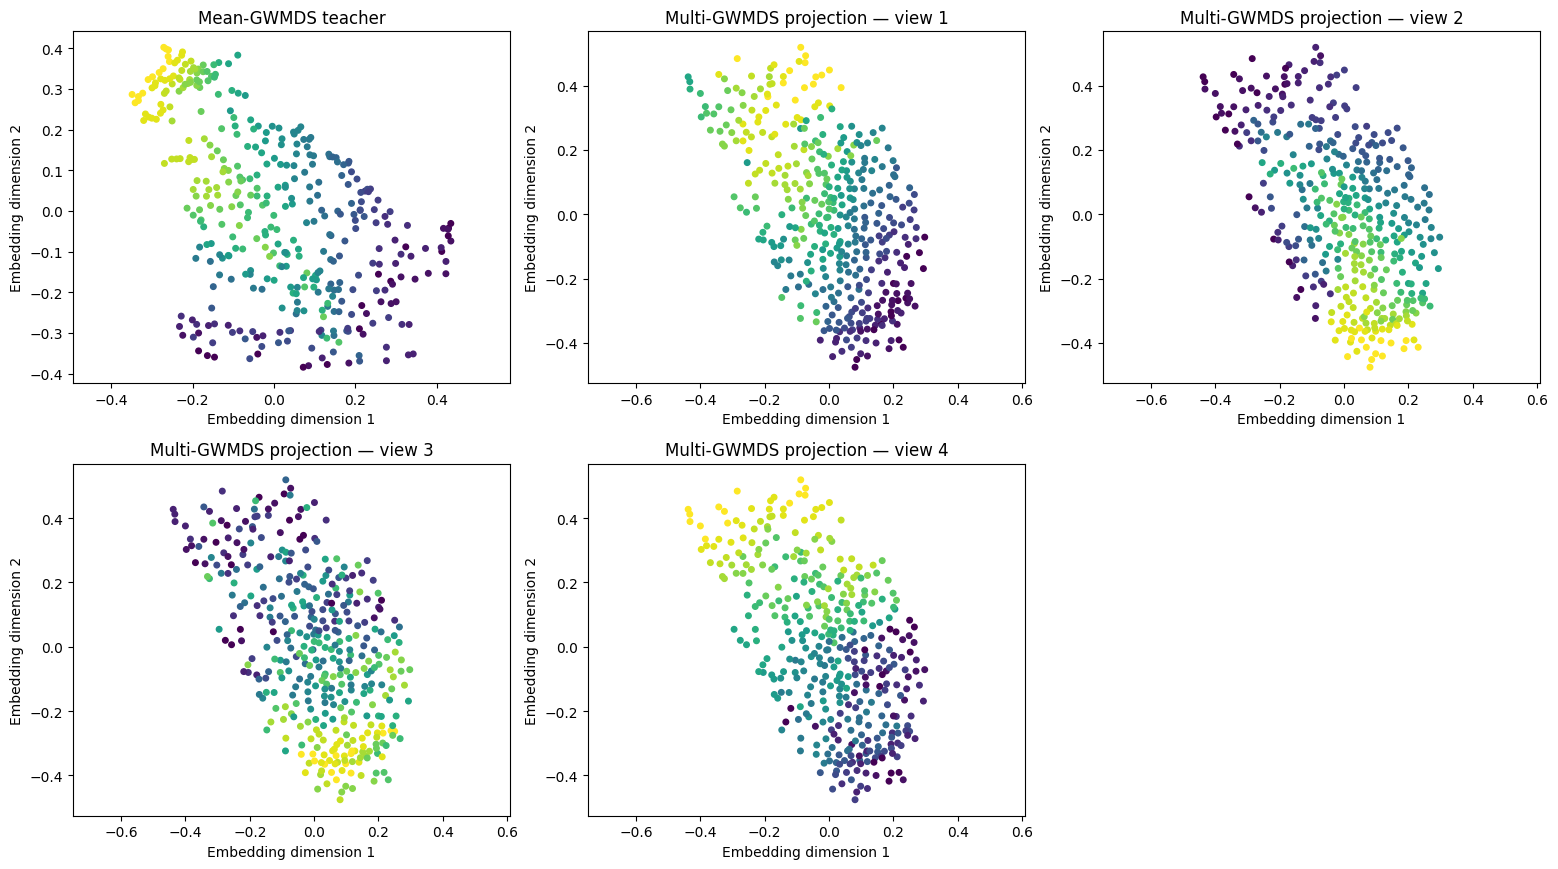

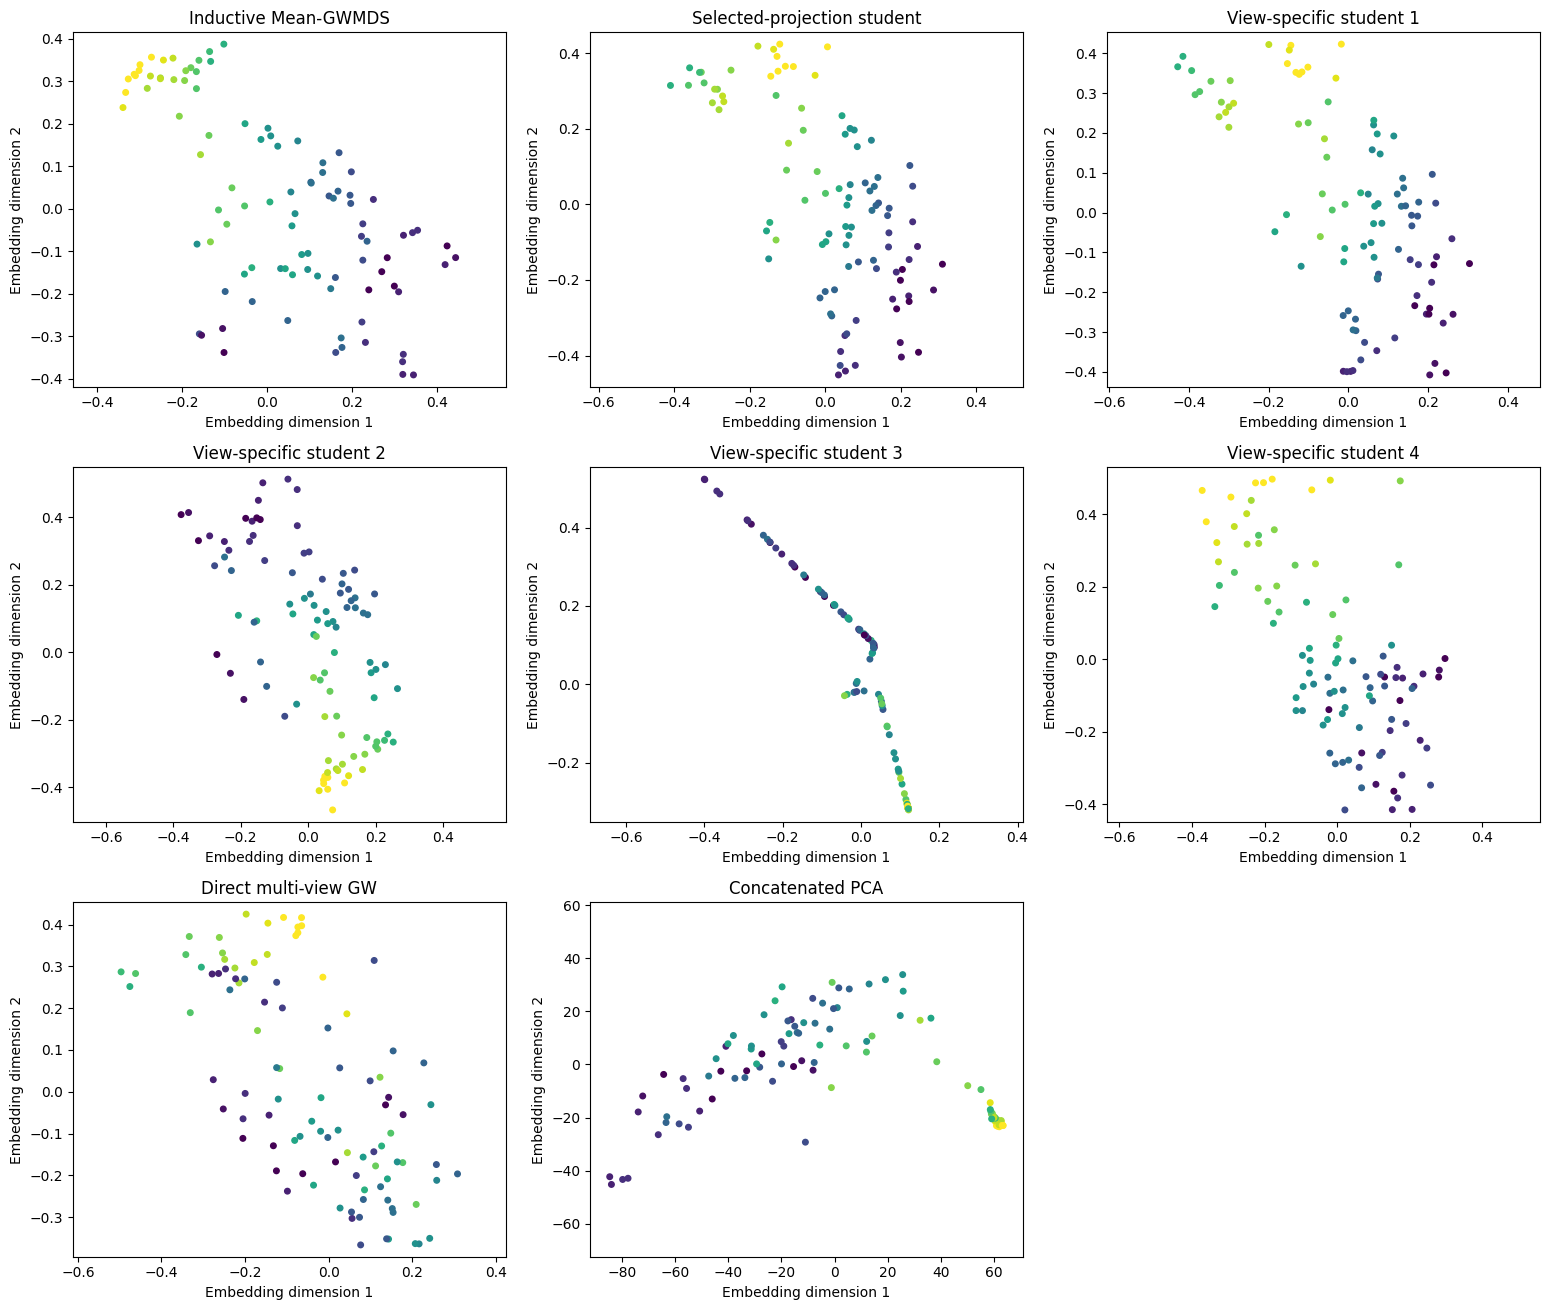

In [ ]:
def plot_embeddings(
    embeddings,
    labels,
    max_columns=3,
    point_size=16,
):
    names = list(embeddings.keys())
    n_plots = len(names)
    n_columns = min(max_columns, n_plots)
    n_rows = math.ceil(n_plots / n_columns)
    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(5.2 * n_columns, 4.4 * n_rows),
        squeeze=False,
    )

    for ax, name in zip(axes.flat, names):
        Y = embeddings[name]
        ax.scatter(
            Y[:, 0],
            Y[:, 1],
            c=labels,
            cmap="viridis",
            s=point_size,
        )
        ax.set_title(name)
        ax.set_xlabel("Embedding dimension 1")
        ax.set_ylabel("Embedding dimension 2")
        ax.set_aspect("equal", adjustable="datalim")

    for ax in list(axes.flat)[n_plots:]:
        ax.axis("off")

    fig.tight_layout()
    return fig


teacher_embeddings = {
    "Mean-GWMDS teacher": Y_mean_teacher_train,
}
for view_index, Y_projection in enumerate(
    multi_teacher["Y_projected_list"]
):
    teacher_embeddings[
        f"Multi-GWMDS projection — view {view_index + 1}"
    ] = Y_projection

fig = plot_embeddings(teacher_embeddings, t_train)
plt.show()

test_embeddings = {
    "Inductive Mean-GWMDS": Y_mean_student_test,
    "Selected-projection student": Y_selected_student_test,
}
for view_index, Y_test in enumerate(Y_view_specific_test):
    test_embeddings[
        f"View-specific student {view_index + 1}"
    ] = Y_test
if RUN_DIRECT_GW:
    test_embeddings["Direct multi-view GW"] = Y_direct_test
test_embeddings["Concatenated PCA"] = Y_pca_test

fig = plot_embeddings(test_embeddings, t_test)
plt.show()


In [ ]:
for name, value in list(globals().items()):
    if (
        isinstance(value, list)
        and len(value) > 0
        and isinstance(value[0], dict)
        and "history_train" in value[0]
    ):
        print(name)

view_specific_students


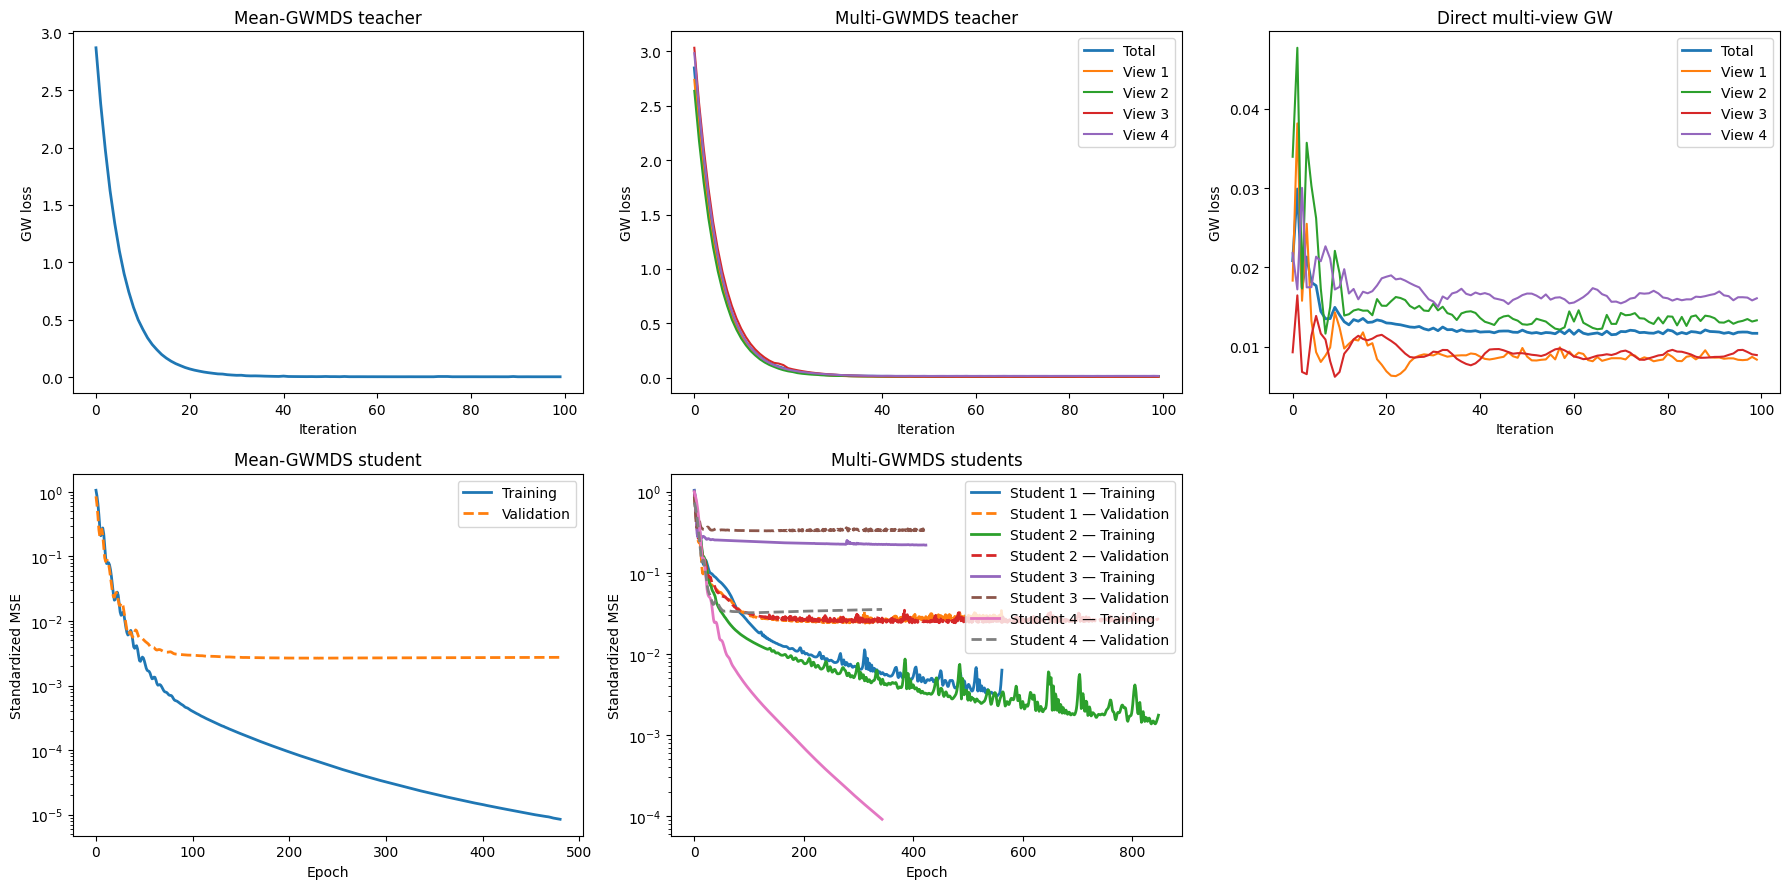

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# ============================================================
# Mean-GWMDS teacher
# ============================================================
axes[0, 0].plot(
    mean_teacher["history"],
    linewidth=2,
)

axes[0, 0].set_title("Mean-GWMDS teacher")
axes[0, 0].set_xlabel("Iteration")
axes[0, 0].set_ylabel("GW loss")


# ============================================================
# Multi-GWMDS teacher
# ============================================================
axes[0, 1].plot(
    multi_teacher["history_total"],
    linewidth=2,
    label="Total",
)

for view_index in range(N_VIEWS):
    axes[0, 1].plot(
        multi_teacher["history_views"][:, view_index],
        linewidth=1.5,
        label=f"View {view_index + 1}",
    )

axes[0, 1].set_title("Multi-GWMDS teacher")
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].set_ylabel("GW loss")
axes[0, 1].legend()


# ============================================================
# Direct multi-view GW
# ============================================================
if RUN_DIRECT_GW:
    axes[0, 2].plot(
        direct_result["history_total"],
        linewidth=2,
        label="Total",
    )

    for view_index in range(N_VIEWS):
        axes[0, 2].plot(
            direct_result["history_views"][:, view_index],
            linewidth=1.5,
            label=f"View {view_index + 1}",
        )

    axes[0, 2].set_title("Direct multi-view GW")
    axes[0, 2].set_xlabel("Iteration")
    axes[0, 2].set_ylabel("GW loss")
    axes[0, 2].legend()

else:
    axes[0, 2].axis("off")


# ============================================================
# Mean-GWMDS student
# ============================================================
axes[1, 0].semilogy(
    mean_student["history_train"],
    linewidth=2,
    label="Training",
)

axes[1, 0].semilogy(
    mean_student["history_validation"],
    linewidth=2,
    linestyle="--",
    label="Validation",
)

axes[1, 0].set_title("Mean-GWMDS student")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Standardized MSE")
axes[1, 0].legend()


# ============================================================
# Multi-GWMDS students
# ============================================================
for view_index, student_result in enumerate(
    view_specific_students
):
    axes[1, 1].semilogy(
        student_result["history_train"],
        linewidth=2,
        label=f"Student {view_index + 1} — Training",
    )

    axes[1, 1].semilogy(
        student_result["history_validation"],
        linewidth=2,
        linestyle="--",
        label=f"Student {view_index + 1} — Validation",
    )

axes[1, 1].set_title("Multi-GWMDS students")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Standardized MSE")
axes[1, 1].legend()


# Painel restante
axes[1, 2].axis("off")

fig.tight_layout()
plt.show()

## 11. Save tables and figures individually

This cell creates PDF files without colorbars, plus CSV tables. It can be executed after all
experiments are complete.


In [ ]:
def safe_filename(text):
    replacements = {
        "—": "-",
        "–": "-",
        " ": "_",
        "/": "_",
    }
    result = text.lower()
    for old, new in replacements.items():
        result = result.replace(old, new)
    return "".join(
        character
        for character in result
        if character.isalnum() or character in {"_", "-"}
    )


def save_embedding_pdf(Y, labels, title, path):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ax.scatter(
        Y[:, 0],
        Y[:, 1],
        c=labels,
        cmap="viridis",
        s=18,
    )
    ax.set_xlabel("Embedding dimension 1")
    ax.set_ylabel("Embedding dimension 2")
    # ax.set_title(title)
    ax.set_aspect("equal", adjustable="datalim")
    fig.tight_layout()
    fig.savefig(path, format="pdf", bbox_inches="tight")
    plt.close(fig)


def save_curve_pdf(curves, xlabel, ylabel, title, path, log_y=False):
    fig, ax = plt.subplots(figsize=(5.5, 4.0))
    for label, values in curves.items():
        if log_y:
            ax.semilogy(values, linewidth=2, label=label)
        else:
            ax.plot(values, linewidth=2, label=label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    # ax.set_title(title)
    if len(curves) > 1:
        ax.legend()
    fig.tight_layout()
    fig.savefig(path, format="pdf", bbox_inches="tight")
    plt.close(fig)


if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    for name, Y in teacher_embeddings.items():
        save_embedding_pdf(
            Y,
            t_train,
            name,
            OUTPUT_DIR / f"{safe_filename(name)}_train.pdf",
        )

    for name, Y in test_embeddings.items():
        save_embedding_pdf(
            Y,
            t_test,
            name,
            OUTPUT_DIR / f"{safe_filename(name)}_test.pdf",
        )

    save_curve_pdf(
        {"GW loss": mean_teacher["history"]},
        "Iteration",
        "GW loss",
        "Mean-GWMDS teacher convergence",
        OUTPUT_DIR / "mean_gwmds_teacher_convergence.pdf",
    )

    multi_curves = {"Total": multi_teacher["history_total"]}
    for view_index in range(N_VIEWS):
        multi_curves[f"View {view_index + 1}"] = (
            multi_teacher["history_views"][:, view_index]
        )
    save_curve_pdf(
        multi_curves,
        "Iteration",
        "GW loss",
        "Multi-GWMDS teacher convergence",
        OUTPUT_DIR / "multi_gwmds_teacher_convergence.pdf",
    )

    save_curve_pdf(
        {
            "Training": mean_student["history_train"],
            "Validation": mean_student["history_validation"],
        },
        "Epoch",
        "Standardized MSE",
        "Mean-GWMDS student distillation",
        OUTPUT_DIR / "mean_gwmds_student_distillation.pdf",
        log_y=True,
    )

    save_curve_pdf(
        {
            "Training": selected_student["history_train"],
            "Validation": selected_student["history_validation"],
        },
        "Epoch",
        "Standardized MSE",
        "Selected-projection student distillation",
        OUTPUT_DIR / "selected_projection_student_distillation.pdf",
        log_y=True,
    )

    for view_index, result in enumerate(view_specific_students):
        save_curve_pdf(
            {
                "Training": result["history_train"],
                "Validation": result["history_validation"],
            },
            "Epoch",
            "Standardized MSE",
            f"View-specific student {view_index + 1}",
            OUTPUT_DIR
            / f"view_specific_student_{view_index + 1}_distillation.pdf",
            log_y=True,
        )

    if RUN_DIRECT_GW:
        direct_curves = {"Total": direct_result["history_total"]}
        for view_index in range(N_VIEWS):
            direct_curves[f"View {view_index + 1}"] = (
                direct_result["history_views"][:, view_index]
            )
        save_curve_pdf(
            direct_curves,
            "Iteration",
            "GW loss",
            "Direct multi-view GW convergence",
            OUTPUT_DIR / "direct_multiview_gw_convergence.pdf",
        )

    evaluation_table.to_csv(
        OUTPUT_DIR / "relational_metrics.csv",
        index=False,
    )
    agreement_table.to_csv(
        OUTPUT_DIR / "projection_agreement.csv",
        index=True,
    )
    execution_table.to_csv(
        OUTPUT_DIR / "execution_times.csv",
        index=False,
    )

    print(f"Results saved in: {OUTPUT_DIR.resolve()}")
    for path in sorted(OUTPUT_DIR.iterdir()):
        print(f"  - {path.name}")


Results saved in: /content/inductive_multiview_era5_results
  - concatenated_pca_test.pdf
  - direct_multi-view_gw_test.pdf
  - direct_multiview_gw_convergence.pdf
  - execution_times.csv
  - inductive_mean-gwmds_test.pdf
  - mean-gwmds_teacher_train.pdf
  - mean_gwmds_student_distillation.pdf
  - mean_gwmds_teacher_convergence.pdf
  - multi-gwmds_projection_-_view_1_train.pdf
  - multi-gwmds_projection_-_view_2_train.pdf
  - multi-gwmds_projection_-_view_3_train.pdf
  - multi-gwmds_projection_-_view_4_train.pdf
  - multi_gwmds_teacher_convergence.pdf
  - projection_agreement.csv
  - relational_metrics.csv
  - selected-projection_student_test.pdf
  - selected_projection_student_distillation.pdf
  - view-specific_student_1_test.pdf
  - view-specific_student_2_test.pdf
  - view-specific_student_3_test.pdf
  - view-specific_student_4_test.pdf
  - view_specific_student_1_distillation.pdf
  - view_specific_student_2_distillation.pdf
  - view_specific_student_3_distillation.pdf
  - view_spec

In [ ]:
def save_multigwmds_students_pdf(student_results, title, path):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    for view_index, result in enumerate(student_results):
        ax.semilogy(
            result["history_train"],
            linewidth=2,
            label=f"Student {view_index + 1} — Training",
        )

        ax.semilogy(
            result["history_validation"],
            linewidth=2,
            linestyle="--",
            label=f"Student {view_index + 1} — Validation",
        )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Standardized MSE")
    # ax.set_title(title)
    ax.legend()

    fig.tight_layout()
    fig.savefig(
        path,
        format="pdf",
        bbox_inches="tight",
    )
    plt.close(fig)

In [ ]:
for view_index, result in enumerate(view_specific_students):
    save_curve_pdf(
        {
            "Training": result["history_train"],
            "Validation": result["history_validation"],
        },
        "Epoch",
        "Standardized MSE",
        f"View-specific student {view_index + 1}",
        OUTPUT_DIR
        / f"view_specific_student_{view_index + 1}_distillation.pdf",
        log_y=True,
    )

In [ ]:
# Curvas conjuntas dos students do Multi-GWMDS
save_multigwmds_students_pdf(
    view_specific_students,
    "Multi-GWMDS students",
    OUTPUT_DIR / "multi_gwmds_students_distillation.pdf",
)

In [ ]:
%cd /content

/content


## 12. Using another multi-view dataset

Replace only the data block and provide:

```python
X_views = [X_view_1, X_view_2, ..., X_view_V]
view_names = ["View 1", "View 2", ..., "View V"]
```

Requirements:

- every array must contain the same \(n\) samples in the same order;
- feature dimensions may differ across views;
- use one shared set of train/test indices;
- keep `D_train_views` restricted to the training data;
- set `VIEW_WEIGHTS` to `None` or a list of \(V\) nonnegative values.

The Multi-GWMDS projections remain distinct:

```python
multi_teacher["Y_projected_list"][v]
```

and the corresponding view-specific inductive predictions are:

```python
Y_view_specific_test[v]
```
